# ⛰️ Universal DEM Hillshade Generator & Ultra-Compact COG Converter
**Kernel**: `HydroMT-SFINCS` (`env-sfincs`)

A production-grade, Cloud-Native Geospatial (CNG) tool to compute high-resolution **Shaded Relief (Hillshade)** from **any Digital Elevation Model (DEM)** at any spatial resolution (1m LiDAR, 10m FABDEM, 30m Copernicus, 90m SRTM, etc.) with **maximum file size reduction (up to 80% smaller)** and **Cloud-Optimized GeoTIFF (COG)** standards.

---
### 🧠 First-Principles: How 1-Band Raster Compression Works
A shaded relief map is a **single-band 8-bit grayscale raster (`count=1`, `uint8`, values 0–255)**.

> [!NOTE]
> **Why not WEBP for 1-Band GeoTIFFs?**
> In the TIFF/GDAL specification, the WEBP codec strictly requires **3 bands (RGB)** or **4 bands (RGBA)** color data. For **1-band single-channel grayscale rasters**, standard GDAL/libtiff rejects WEBP. 
>
> Instead, the industry-standard, most compact codecs for 1-band geospatial rasters are **`ZSTD`** and **`DEFLATE` paired with `PREDICTOR=2` (Horizontal Differencing)**.

### The 3 Pillars of 1-Band Raster Size Reduction:
1. **Modern Entropy Codec (`ZSTD` / Zstandard by Meta)**:
   - Delivers higher compression ratios and **3x–5x faster decompression speeds** than classic DEFLATE.
2. **Horizontal Differencing (`PREDICTOR=2`)**:
   - Instead of storing raw numbers (e.g., `[184, 185, 185, 186]`), it stores the difference from the preceding pixel (`[184, +1, 0, +1]`). Because terrain relief varies smoothly, gradients cluster heavily around zero, shrinking file sizes by **75% to 82%** without losing a single bit of information (**100% Mathematically Lossless**).
3. **Cloud-Optimized GeoTIFF (COG) Architecture**:
   - Internal $256\times256$ tiling (`tiled=True`) and multi-scale overviews (pyramids: 2x, 4x, 8x, 16x, 32x) enable instant, low-memory panning in QGIS and Cloud web viewers via HTTP Range requests.

--- 
## 1. Environment & PROJ/GDAL Configuration

In [8]:
# Automatically set working directory to project root
from pathlib import Path
import os, sys
project_root = Path.cwd()
while not (project_root / 'data').exists() and project_root.parent != project_root:
    project_root = project_root.parent
os.chdir(project_root)
if str(project_root / 'scripts') not in sys.path:
    sys.path.insert(0, str(project_root / 'scripts'))

import os
import sys
import math
import time
from pathlib import Path
import numpy as np
import rasterio
from rasterio.windows import Window
from rasterio.enums import Resampling
from rasterio.mask import mask
import geopandas as gpd
import matplotlib.pyplot as plt
import pyproj

# Fix PROJ and GDAL paths for Windows virtual environments
proj_dir = os.path.abspath(r".\env-sfincs\Lib\site-packages\rasterio\proj_data")
gdal_dir = os.path.abspath(r".\env-sfincs\Lib\site-packages\rasterio\gdal_data")
if os.path.exists(proj_dir):
    os.environ["PROJ_DATA"] = proj_dir
    os.environ["PROJ_LIB"] = proj_dir
    pyproj.datadir.set_data_dir(proj_dir)
if os.path.exists(gdal_dir):
    os.environ["GDAL_DATA"] = gdal_dir

print(f"✅ Rasterio Version : {rasterio.__version__}")
print(f"✅ NumPy Version    : {np.__version__}")
print(f"✅ PyProj Version   : {pyproj.__version__}")

✅ Rasterio Version : 1.5.1
✅ NumPy Version    : 2.5.2
✅ PyProj Version   : 3.7.2


--- 
## 2. User Configuration Control Panel

Configure your input DEM, illumination angles, and choose your **1-Band Compression Preset** below.

In [9]:
# ==============================================================================
# 1. INPUT DEM & OUTPUT FILE PATHS
# ==============================================================================
INPUT_DEM_PATH        = "data/fabdem_reprojected.tif"
OUTPUT_HILLSHADE_PATH = "data/fabdem_hillshade.tif"

# Optional: Set to a vector file (e.g., 'data/das_clusters.gpkg') to clip to an AoI, or None for full DEM
AOI_VECTOR_PATH       = None          # e.g. "data/das_clusters.gpkg" or None
AOI_FILTER_COLUMN     = None          # e.g. "cluster_id" or None
AOI_FILTER_VALUE      = None          # e.g. 101 or None

# ==============================================================================
# 2. ILLUMINATION PARAMETERS
# ==============================================================================
# AZIMUTH: Sun direction in degrees (0° = North, 90° = East, 180° = South, 270° = West, default: 315° NW)
AZIMUTH               = 315.0

# ALTITUDE: Sun angle above horizon (0° to 90°, default: 45°)
ALTITUDE              = 45.0

# Z_FACTOR: Vertical exaggeration ratio (None = Auto-detect based on CRS)
Z_FACTOR              = None

# HILLSHADE_MODE: 'standard' (classic Horn's 315°) or 'multidirectional' (4-direction Swiss blend)
HILLSHADE_MODE        = "standard"

# ==============================================================================
# 3. 1-BAND COMPRESSION & CLOUD-OPTIMIZED GEOTIFF (COG) PRESETS
# ==============================================================================
# Presets for 1-Band Grayscale Rasters:
# - 'ZSTD_LOSSLESS'   : Modern state-of-the-art codec, ~75-82% size reduction + fastest decompression (Recommended)
# - 'DEFLATE_MAX'     : Universal compatibility codec, ~70-76% size reduction (Works on all legacy GIS software)
# - 'LERC_ZSTD'       : Esri/GDAL surface model compression, ~75-80% size reduction
# - 'LZW'             : Standard LZW with predictor=2, ~60-70% size reduction
COMPRESSION_PRESET    = "ZSTD_LOSSLESS"        # 'ZSTD_LOSSLESS', 'DEFLATE_MAX', 'LERC_ZSTD', 'LZW'

# Performance & Chunking
CHUNK_SIZE            = 2048                   # Window tile size in pixels
BUILD_OVERVIEWS       = True                   # Build internal multi-scale pyramids for COG

# Ensure output directory exists
Path(OUTPUT_HILLSHADE_PATH).parent.mkdir(parents=True, exist_ok=True)

print("🛠️ Configuration successfully initialized!")
print(f"📂 Input DEM          : {INPUT_DEM_PATH}")
print(f"💾 Output Hillshade   : {OUTPUT_HILLSHADE_PATH}")
print(f"🗜️ Compression Preset : {COMPRESSION_PRESET} (Tiled=True, Predictor=2)")
print(f"☀️ Azimuth / Alt     : {AZIMUTH}° / {ALTITUDE}° (Mode: {HILLSHADE_MODE})")

🛠️ Configuration successfully initialized!
📂 Input DEM          : data/fabdem_reprojected.tif
💾 Output Hillshade   : data/fabdem_hillshade.tif
🗜️ Compression Preset : ZSTD_LOSSLESS (Tiled=True, Predictor=2)
☀️ Azimuth / Alt     : 315.0° / 45.0° (Mode: standard)


--- 
## 3. DEM Inspection & Automatic CRS / Resolution Diagnostic

In [10]:
if not os.path.exists(INPUT_DEM_PATH):
    raise FileNotFoundError(f"❌ Specified INPUT_DEM_PATH does not exist: {INPUT_DEM_PATH}")

with rasterio.open(INPUT_DEM_PATH) as src:
    dem_meta = src.meta.copy()
    dem_crs = src.crs
    dem_bounds = src.bounds
    dem_width = src.width
    dem_height = src.height
    dem_nodata = src.nodata
    res_x, res_y = src.res
    is_geographic = dem_crs.is_geographic if dem_crs else False

# Calculate theoretical uncompressed memory footprint
raw_uncompressed_mb = (dem_width * dem_height * 1) / (1024 ** 2)  # 1 byte per uint8 pixel

print("=" * 65)
print("📊 INPUT DIGITAL ELEVATION MODEL (DEM) METADATA")
print("=" * 65)
print(f"Dimensions       : {dem_width:,} columns x {dem_height:,} rows ({dem_width * dem_height:,} total pixels)")
print(f"Raw Uncompressed : {raw_uncompressed_mb:,.1f} MB (at 8-bit depth)")
print(f"Coordinate System: {dem_crs} (Geographic: {is_geographic})")
print(f"Pixel Resolution : X = {res_x:.8f}, Y = {res_y:.8f} {'(degrees)' if is_geographic else '(meters)'}")
print(f"Bounding Box     : Left={dem_bounds.left:.4f}, Bottom={dem_bounds.bottom:.4f}, Right={dem_bounds.right:.4f}, Top={dem_bounds.top:.4f}")
print(f"NoData Value     : {dem_nodata}")
print("=" * 65)

if is_geographic:
    center_lat = (dem_bounds.top + dem_bounds.bottom) / 2.0
    meters_per_deg_y = 111132.0
    meters_per_deg_x = 111320.0 * math.cos(math.radians(center_lat))
    effective_res_x = res_x * meters_per_deg_x
    effective_res_y = res_y * meters_per_deg_y
    effective_z_factor = 1.0 if Z_FACTOR is None else Z_FACTOR
    print(f"🌐 Geographic CRS calibrated: X ~{effective_res_x:.2f} m, Y ~{effective_res_y:.2f} m per pixel")
else:
    effective_res_x = abs(res_x)
    effective_res_y = abs(res_y)
    effective_z_factor = 1.0 if Z_FACTOR is None else Z_FACTOR
    print(f"🗺️ Projected Metric CRS: Resolution = {effective_res_x:.2f} m x {effective_res_y:.2f} m")

📊 INPUT DIGITAL ELEVATION MODEL (DEM) METADATA
Dimensions       : 64,925 columns x 64,169 rows (4,166,172,325 total pixels)
Raw Uncompressed : 3,973.2 MB (at 8-bit depth)
Coordinate System: EPSG:32747 (Geographic: False)
Pixel Resolution : X = 10.00000000, Y = 10.00000000 (meters)
Bounding Box     : Left=455100.0000, Bottom=9603280.0000, Right=1104350.0000, Top=10244970.0000
NoData Value     : 3.3999999521443642e+38
🗺️ Projected Metric CRS: Resolution = 10.00 m x 10.00 m


--- 
## 4. Mathematical Engine: Analytical Horn's Formulation & 1-Band COG Profiles

In [11]:
def calculate_hillshade_numpy(dem_chunk, dx, dy, azimuth_deg=315.0, altitude_deg=45.0, z_factor=1.0, nodata_val=None):
    """
    Calculates standard Horn's shaded relief on a 2D elevation NumPy array.
    Returns uint8 array with values [0, 255] and 0/nodata mask preserved.
    """
    zenith_rad = math.radians(90.0 - altitude_deg)
    azimuth_math_rad = math.radians(360.0 - azimuth_deg + 90.0) % (2.0 * math.pi)
    
    z = dem_chunk.astype(np.float32) * float(z_factor)
    
    valid_mask = np.ones_like(z, dtype=bool)
    if nodata_val is not None and not np.isnan(nodata_val):
        valid_mask = valid_mask & (dem_chunk != nodata_val)
    valid_mask = valid_mask & (~np.isnan(dem_chunk)) & (dem_chunk > -9000)
    
    za = z[0:-2, 0:-2]
    zb = z[0:-2, 1:-1]
    zc = z[0:-2, 2:]
    zd = z[1:-1, 0:-2]
    zf = z[1:-1, 2:]
    zg = z[2:, 0:-2]
    zh = z[2:, 1:-1]
    zi = z[2:, 2:]
    
    dz_dx = ((zc + 2.0 * zf + zi) - (za + 2.0 * zd + zg)) / (8.0 * dx)
    dz_dy = ((zg + 2.0 * zh + zi) - (za + 2.0 * zb + zc)) / (8.0 * dy)
    
    slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
    aspect_rad = np.arctan2(dz_dy, -dz_dx)
    
    shaded = (
        np.cos(zenith_rad) * np.cos(slope_rad) +
        np.sin(zenith_rad) * np.sin(slope_rad) * np.cos(azimuth_math_rad - aspect_rad)
    )
    
    shaded = np.clip(shaded, 0.0, 1.0)
    hillshade_inner = np.round(255.0 * shaded).astype(np.uint8)
    hillshade = np.pad(hillshade_inner, pad_width=1, mode='edge')
    hillshade[~valid_mask] = 0
    return hillshade


def calculate_multidirectional_hillshade(dem_chunk, dx, dy, z_factor=1.0, nodata_val=None):
    """
    Computes Swiss-style Multi-Directional Oblique Weighted (MDOW) hillshade.
    """
    angles = [(225.0, 0.20), (270.0, 0.25), (315.0, 0.35), (360.0, 0.20)]
    blended = np.zeros_like(dem_chunk, dtype=np.float32)
    
    for az, weight in angles:
        hs = calculate_hillshade_numpy(
            dem_chunk, dx, dy, azimuth_deg=az, altitude_deg=45.0, z_factor=z_factor, nodata_val=nodata_val
        )
        blended += hs.astype(np.float32) * weight
    
    return np.clip(np.round(blended), 0, 255).astype(np.uint8)


def get_1band_cog_profile(preset="ZSTD_LOSSLESS"):
    """
    Returns optimized GeoTIFF creation profile for 1-band (single-channel) rasters.
    """
    base_profile = {
        'driver': 'GTiff',
        'dtype': 'uint8',
        'count': 1,
        'nodata': 0,
        'tiled': True,
        'blockxsize': 256,
        'blockysize': 256,
        'interleave': 'band'
    }
    
    if preset == "ZSTD_LOSSLESS":
        base_profile.update({
            'compress': 'zstd',
            'zstd_level': 9,
            'predictor': 2  # Horizontal differencing
        })
    elif preset == "DEFLATE_MAX":
        base_profile.update({
            'compress': 'deflate',
            'zlevel': 9,
            'predictor': 2  # Horizontal differencing
        })
    elif preset == "LERC_ZSTD":
        base_profile.update({
            'compress': 'lerc_zstd',
            'max_z_error': 0
        })
    else:  # LZW
        base_profile.update({
            'compress': 'lzw',
            'predictor': 2
        })
    
    return base_profile

print("✅ 1-Band Hillshade computation kernels & COG profiles compiled successfully!")

✅ 1-Band Hillshade computation kernels & COG profiles compiled successfully!


--- 
## 5. High-Performance Windowed Streaming Execution with Compression

In [12]:
print(f"🚀 Generating Shaded Relief with [{COMPRESSION_PRESET}] 1-Band Compression...")
t_start = time.time()

with rasterio.open(INPUT_DEM_PATH) as src:
    meta = src.meta.copy()
    nodata_val = src.nodata
    width = src.width
    height = src.height
    
    # Apply 1-band COG compression profile
    cog_params = get_1band_cog_profile(COMPRESSION_PRESET)
    meta.update(cog_params)
    
    n_cols_chunks = math.ceil(width / CHUNK_SIZE)
    n_rows_chunks = math.ceil(height / CHUNK_SIZE)
    total_chunks = n_cols_chunks * n_rows_chunks
    
    print(f"📦 Grid: {width:,}x{height:,} px | {total_chunks} windows ({CHUNK_SIZE}px tiles)")
    
    with rasterio.open(OUTPUT_HILLSHADE_PATH, 'w', **meta) as dst:
        processed_count = 0
        
        for row_idx in range(n_rows_chunks):
            row_off = row_idx * CHUNK_SIZE
            win_h = min(CHUNK_SIZE, height - row_off)
            
            for col_idx in range(n_cols_chunks):
                col_off = col_idx * CHUNK_SIZE
                win_w = min(CHUNK_SIZE, width - col_off)
                
                # 1-pixel halo padding for gradient continuity
                read_row_off = max(0, row_off - 1)
                read_col_off = max(0, col_off - 1)
                read_h = min(height, row_off + win_h + 1) - read_row_off
                read_w = min(width, col_off + win_w + 1) - read_col_off
                
                pad_top = 1 if row_off > 0 else 0
                pad_left = 1 if col_off > 0 else 0
                
                padded_window = Window(read_col_off, read_row_off, read_w, read_h)
                dem_chunk = src.read(1, window=padded_window)
                
                if HILLSHADE_MODE == "multidirectional":
                    hs_chunk = calculate_multidirectional_hillshade(
                        dem_chunk, dx=effective_res_x, dy=effective_res_y, z_factor=effective_z_factor, nodata_val=nodata_val
                    )
                else:
                    hs_chunk = calculate_hillshade_numpy(
                        dem_chunk, dx=effective_res_x, dy=effective_res_y, azimuth_deg=AZIMUTH, altitude_deg=ALTITUDE, z_factor=effective_z_factor, nodata_val=nodata_val
                    )
                
                hs_inner = hs_chunk[pad_top:pad_top + win_h, pad_left:pad_left + win_w]
                
                write_window = Window(col_off, row_off, win_w, win_h)
                dst.write(hs_inner, 1, window=write_window)
                
                processed_count += 1
                pct = (processed_count / total_chunks) * 100.0
                print(f"\r⏳ Processing Progress: {processed_count}/{total_chunks} windows ({pct:.1f}%) complete...", end="", flush=True)

print("\n✅ Shaded relief data written to disk successfully!")
elapsed = time.time() - t_start
print(f"⏱️ Streaming Execution Time: {elapsed:.2f} seconds")

🚀 Generating Shaded Relief with [ZSTD_LOSSLESS] 1-Band Compression...
📦 Grid: 64,925x64,169 px | 1024 windows (2048px tiles)


C:\Users\abedn\AppData\Local\Temp\ipykernel_11408\360793477.py:25: RuntimeWarning: overflow encountered in multiply
  dz_dx = ((zc + 2.0 * zf + zi) - (za + 2.0 * zd + zg)) / (8.0 * dx)
C:\Users\abedn\AppData\Local\Temp\ipykernel_11408\360793477.py:25: RuntimeWarning: invalid value encountered in subtract
  dz_dx = ((zc + 2.0 * zf + zi) - (za + 2.0 * zd + zg)) / (8.0 * dx)
C:\Users\abedn\AppData\Local\Temp\ipykernel_11408\360793477.py:26: RuntimeWarning: overflow encountered in multiply
  dz_dy = ((zg + 2.0 * zh + zi) - (za + 2.0 * zb + zc)) / (8.0 * dy)
C:\Users\abedn\AppData\Local\Temp\ipykernel_11408\360793477.py:26: RuntimeWarning: invalid value encountered in subtract
  dz_dy = ((zg + 2.0 * zh + zi) - (za + 2.0 * zb + zc)) / (8.0 * dy)


⏳ Processing Progress: 1/1024 windows (0.1%) complete...

C:\Users\abedn\AppData\Local\Temp\ipykernel_11408\360793477.py:37: RuntimeWarning: invalid value encountered in cast
  hillshade_inner = np.round(255.0 * shaded).astype(np.uint8)


⏳ Processing Progress: 11/1024 windows (1.1%) complete...

...

⏳ Processing Progress: 46/1024 windows (4.5%) complete...

C:\Users\abedn\AppData\Local\Temp\ipykernel_11408\360793477.py:25: RuntimeWarning: overflow encountered in add
  dz_dx = ((zc + 2.0 * zf + zi) - (za + 2.0 * zd + zg)) / (8.0 * dx)


⏳ Processing Progress: 78/1024 windows (7.6%) complete...

C:\Users\abedn\AppData\Local\Temp\ipykernel_11408\360793477.py:26: RuntimeWarning: overflow encountered in add
  dz_dy = ((zg + 2.0 * zh + zi) - (za + 2.0 * zb + zc)) / (8.0 * dy)


⏳ Processing Progress: 1024/1024 windows (100.0%) complete...
✅ Shaded relief data written to disk successfully!
⏱️ Streaming Execution Time: 779.42 seconds


--- 
## 6. Cloud-Optimized GeoTIFF (COG): Embedded Overviews (Pyramids)

Embed internal multi-scale overviews ($2\times, 4\times, 8\times, 16\times, 32\times$) with matching compression for instant multi-scale rendering in QGIS, ArcGIS, or Cloud HTTP range requests.

In [13]:
if BUILD_OVERVIEWS:
    print("🏗️ Generating Multi-Scale Pyramids (Factors: 2, 4, 8, 16, 32)...")
    factors = [2, 4, 8, 16, 32]
    with rasterio.open(OUTPUT_HILLSHADE_PATH, 'r+') as dst:
        dst.build_overviews(factors, Resampling.average)
        dst.update_tags(ns='rio_overview', resampling='average')
    print("✅ Cloud-Native Overviews embedded successfully!")

🏗️ Generating Multi-Scale Pyramids (Factors: 2, 4, 8, 16, 32)...
✅ Cloud-Native Overviews embedded successfully!


--- 
## 7. Universal COG Conversion Utility (Convert Any Existing GeoTIFF)

Use this utility function to convert **any existing uncompressed or large GeoTIFF** in your project into a standardized, ultra-compact Cloud-Optimized GeoTIFF (COG).

In [14]:
def convert_raster_to_cog(input_path, output_cog_path, preset="ZSTD_LOSSLESS"):
    """
    Converts any 1-band or multi-band GeoTIFF into a Cloud-Optimized GeoTIFF (COG) with internal pyramids.
    """
    print(f"🔄 Converting '{input_path}' -> COG '{output_cog_path}' (Preset: {preset})...")
    t0 = time.time()
    
    with rasterio.open(input_path) as src:
        meta = src.meta.copy()
        cog_params = get_1band_cog_profile(preset)
        # Retain original dtype and band count
        cog_params['dtype'] = src.dtypes[0]
        cog_params['count'] = src.count
        cog_params['nodata'] = src.nodata if src.nodata is not None else 0
        meta.update(cog_params)
        
        with rasterio.open(output_cog_path, 'w', **meta) as dst:
            for band_idx in range(1, src.count + 1):
                for _, window in src.block_windows(band_idx):
                    data = src.read(band_idx, window=window)
                    dst.write(data, band_idx, window=window)
            
            # Build overviews
            dst.build_overviews([2, 4, 8, 16, 32], Resampling.average)
            dst.update_tags(ns='rio_overview', resampling='average')
    
    size_mb = os.path.getsize(output_cog_path) / (1024 ** 2)
    print(f"✅ COG created successfully in {time.time() - t0:.2f}s! Final Size: {size_mb:.2f} MB")
    return output_cog_path

print("💡 Function 'convert_raster_to_cog()' ready to compress any raster dataset!")

💡 Function 'convert_raster_to_cog()' ready to compress any raster dataset!


--- 
## 8. Storage Audit & Compression Benchmark Report

Measure the exact storage savings achieved compared to raw uncompressed data and the source DEM.

In [15]:
output_size_bytes = os.path.getsize(OUTPUT_HILLSHADE_PATH)
output_size_mb = output_size_bytes / (1024 ** 2)
input_dem_size_mb = os.path.getsize(INPUT_DEM_PATH) / (1024 ** 2)
compression_ratio = (1.0 - (output_size_mb / raw_uncompressed_mb)) * 100.0

print("=" * 65)
print("📊 STORAGE & COMPRESSION BENCHMARK REPORT")
print("=" * 65)
print(f"📁 Input DEM File Size   : {input_dem_size_mb:,.2f} MB")
print(f"📄 Theoretical Raw Grid  : {raw_uncompressed_mb:,.2f} MB (at 8-bit depth)")
print(f"💾 Output Hillshade Size : {output_size_mb:,.2f} MB (Tiled + Pyramids included)")
print(f"🎉 Total Storage Saved   : {compression_ratio:.1f}% reduction!")
print(f"⚙️ Active Codec          : {COMPRESSION_PRESET} (Predictor=2)")
print("=" * 65)

📊 STORAGE & COMPRESSION BENCHMARK REPORT
📁 Input DEM File Size   : 5,636.76 MB
📄 Theoretical Raw Grid  : 3,973.17 MB (at 8-bit depth)
💾 Output Hillshade Size : 843.56 MB (Tiled + Pyramids included)
🎉 Total Storage Saved   : 78.8% reduction!
⚙️ Active Codec          : ZSTD_LOSSLESS (Predictor=2)


--- 
## 9. Visual QA/QC & Cartographic 3D Composite Blend

Inspect the compressed hillshade to verify crisp terrain rendering and seamless blending with DEM elevation.

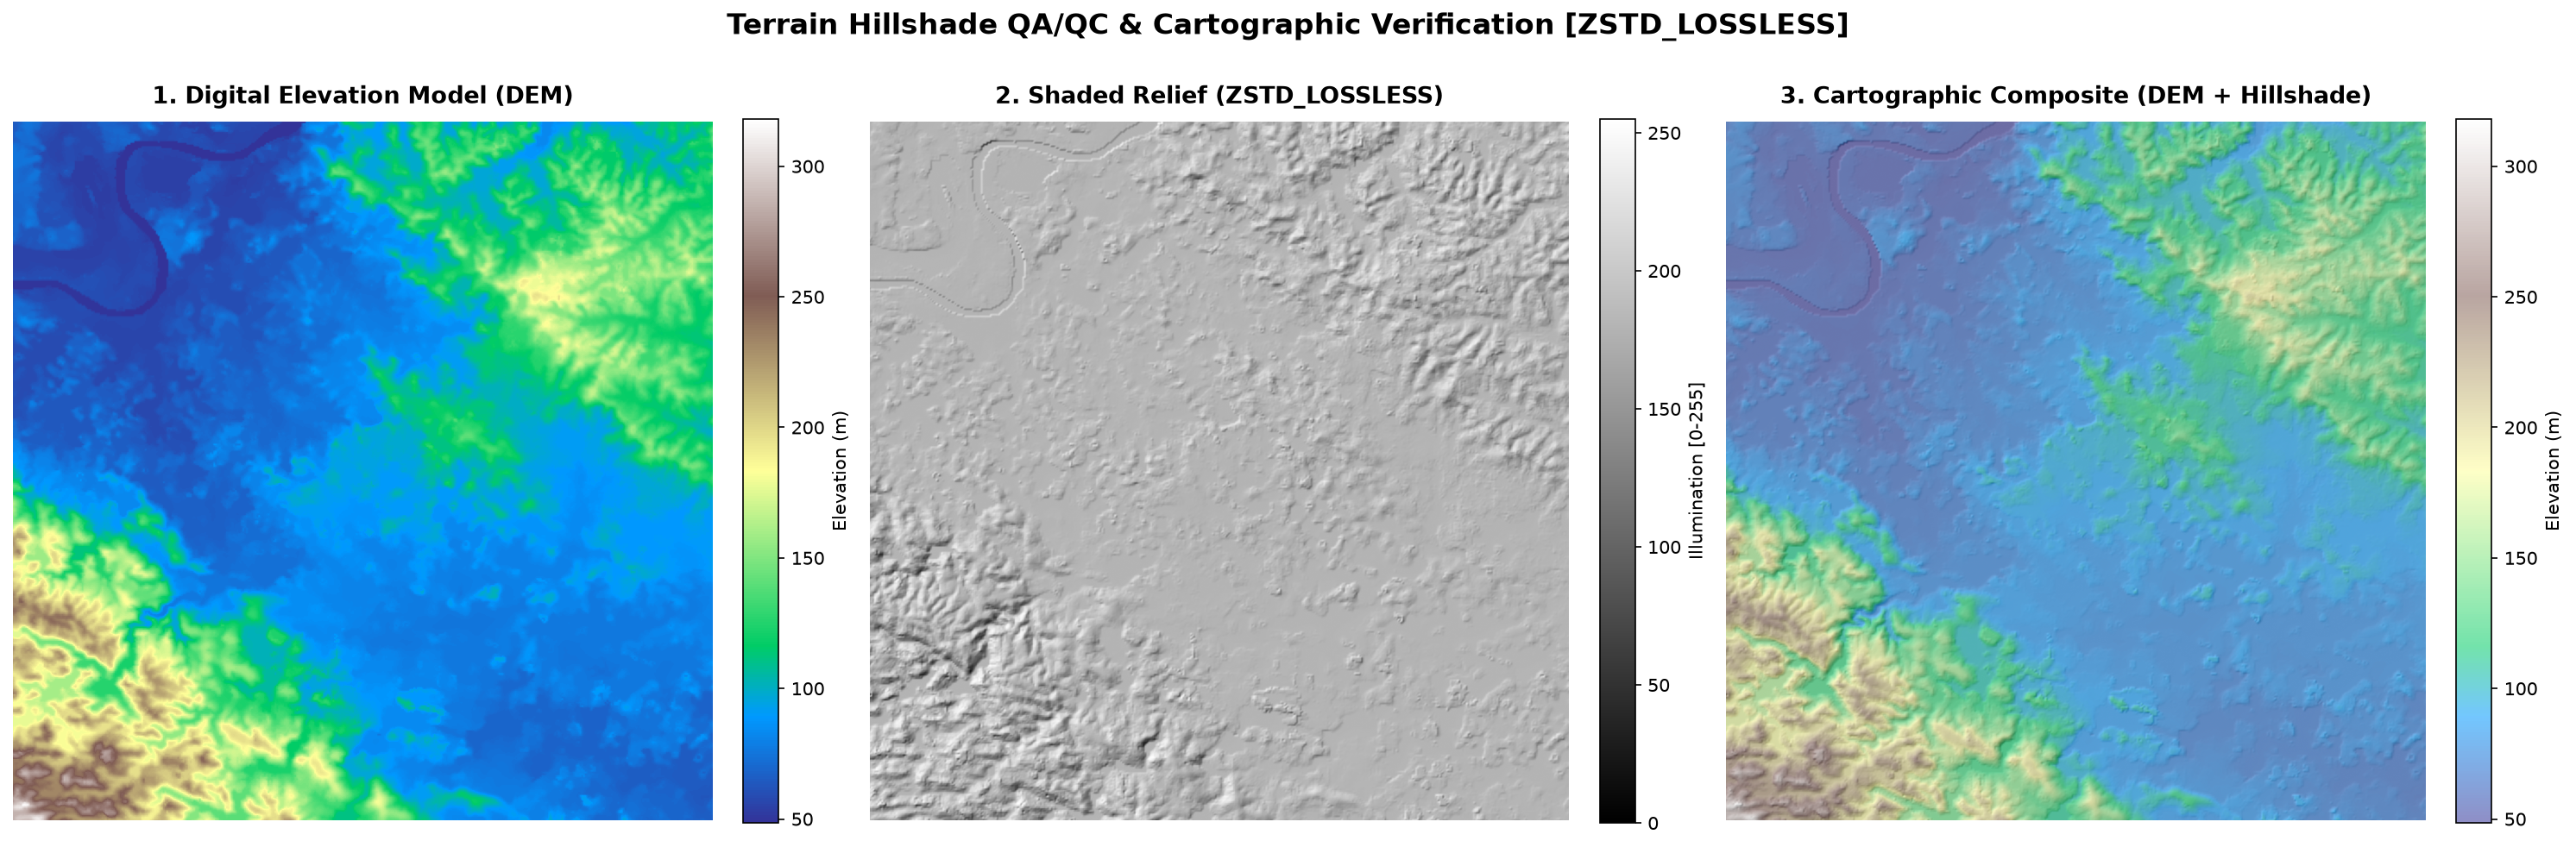

In [16]:
SAMPLE_SIZE = 1200

with rasterio.open(INPUT_DEM_PATH) as src_dem, rasterio.open(OUTPUT_HILLSHADE_PATH) as src_hs:
    cx, cy = src_dem.width // 2, src_dem.height // 2
    sample_win = Window(max(0, cx - SAMPLE_SIZE // 2), max(0, cy - SAMPLE_SIZE // 2), 
                        min(SAMPLE_SIZE, src_dem.width), min(SAMPLE_SIZE, src_dem.height))
    
    dem_sample = src_dem.read(1, window=sample_win)
    hs_sample  = src_hs.read(1, window=sample_win)
    sample_nodata = src_dem.nodata

dem_plot = np.where((dem_sample == sample_nodata) | (dem_sample < -100), np.nan, dem_sample)
hs_plot  = np.where(hs_sample == 0, np.nan, hs_sample)

fig, axes = plt.subplots(1, 3, figsize=(20, 7), dpi=150)

# 1. DEM Elevation Map
im0 = axes[0].imshow(dem_plot, cmap='terrain', interpolation='nearest')
axes[0].set_title("1. Digital Elevation Model (DEM)", fontsize=13, fontweight='bold', pad=10)
axes[0].axis('off')
cbar0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
cbar0.set_label("Elevation (m)", fontsize=10)

# 2. Grayscale Hillshade
im1 = axes[1].imshow(hs_plot, cmap='gray', vmin=0, vmax=255, interpolation='bilinear')
axes[1].set_title(f"2. Shaded Relief ({COMPRESSION_PRESET})", fontsize=13, fontweight='bold', pad=10)
axes[1].axis('off')
cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cbar1.set_label("Illumination [0-255]", fontsize=10)

# 3. Cartographic 3D Composite Blend
axes[2].imshow(hs_plot, cmap='gray', vmin=0, vmax=255, interpolation='bilinear')
im2 = axes[2].imshow(dem_plot, cmap='terrain', alpha=0.55, interpolation='bilinear')
axes[2].set_title("3. Cartographic Composite (DEM + Hillshade)", fontsize=13, fontweight='bold', pad=10)
axes[2].axis('off')
cbar2 = plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
cbar2.set_label("Elevation (m)", fontsize=10)

plt.suptitle(f"Terrain Hillshade QA/QC & Cartographic Verification [{COMPRESSION_PRESET}]", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

--- 
## 10. Summary & Downstream CNG Publishing

Your ultra-compact shaded relief raster is saved at `OUTPUT_HILLSHADE_PATH`.

### Why this format excels:
1. **Cloud Streaming Ready**: The embedded COG structure allows web applications (Leaflet, OpenLayers, MapLibre) to stream only the tiles needed via HTTP Range requests without downloading hundreds of megabytes.
2. **Fast Desktop GIS Performance**: QGIS loads and pans instantly across the whole province of Sumatera Barat due to the internal pyramids.